In [1]:
from shared_2D import *

# Problem setup
- 49 x 50 atoms.
- normalized interatomic-spacing $2^{1/6}$
- outermost 3 layers are atomistic
- no point defects
- initial 5 rep-atoms are handpicked and then kmeans-equilibrated
- boundary conditions 
    - atom at origin is fixed in x and y direction
    - atoms along x-axis are constrained in y
    - atom along y-axis are constrained in x

## Global params

In [3]:
# global params
nx, ny = 49, 50
spacing = 2**(1/6)
border_layers = 3
cutoff = 1.9 * spacing
PINN_HISTORY_JSON_FILENAME = "pinn_history/pinn-history-2d-recluster-energyvar.json"

## Generate lattice
- split into `continuum` and `atomistic` atoms. Outer 3 layers of atoms are made `atomistic`
- manually pick 5 `rep-atoms` evenly distributed
- equilibrate the `rep-atoms` using `kmeans_unweighted`

number of atoms 		 2450
atomistic atoms 		 558
continuum atoms 		 1892
initial rep atom indices 	 [1200  350  384 2065 2099]
final rep atom indices 		 [1200  600  624 1825 1849]
weights 			 [302. 394. 395. 399. 402.]
sum of weights 			 1892.0


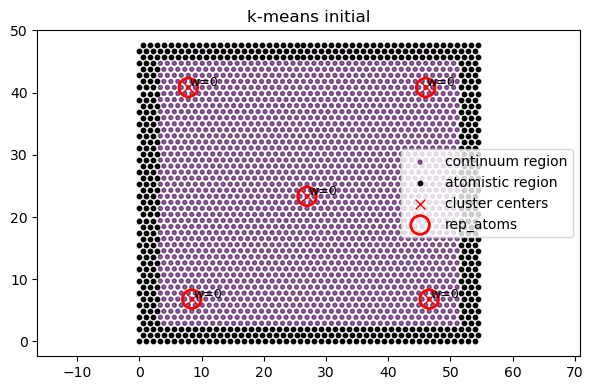

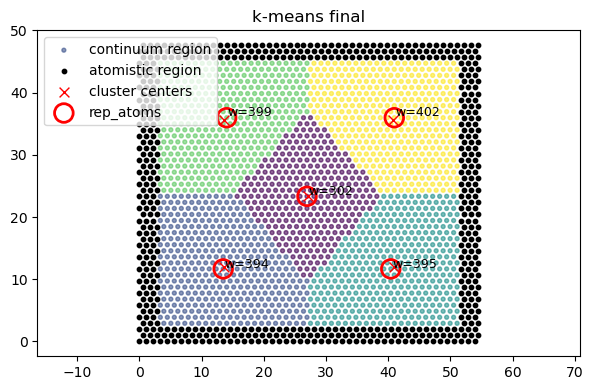

In [4]:
# generate lattice
atom_pos = make_triangular_lattice(nx,ny,spacing)

# 3 layers of atoms bordering the square are flagged as atomistic-region
atomistic_indices,continuum_indices = split_atomistic_continuum(nx,ny,border_layers)
continuum_atom_pos = atom_pos[continuum_indices]
atomistic_atom_pos = atom_pos[atomistic_indices]

# manually pick 5 rep_atoms among the continuum atoms 
initial_rep_indices, rep_targets = pick_manual_rep_atoms(atom_pos,continuum_indices,0.1)

# assign continuum-atoms to their clusters, and equilibrate over 100 iterations of kmeans 
cluster_idx, centers, rep_indices, weights, history = kmeans_unweighted(atom_pos,continuum_indices,initial_rep_indices)

print("number of atoms \t\t", len(atom_pos))
print("atomistic atoms \t\t", len(atomistic_indices))
print("continuum atoms \t\t", len(continuum_indices))
print("initial rep atom indices \t", initial_rep_indices)
print("final rep atom indices \t\t", rep_indices)
print("weights \t\t\t", weights)
print("sum of weights \t\t\t", weights.sum())


plot_partition(atom_pos, atomistic_indices, continuum_indices, [0]*len(continuum_indices), initial_rep_indices, atom_pos[initial_rep_indices],[0 for i in range(initial_rep_indices.size)], figure_size=(6,4),plot_title="k-means initial")
plot_partition(atom_pos, atomistic_indices, continuum_indices, cluster_idx, rep_indices, centers,weights, figure_size=(6,4),plot_title="k-means final")

### Setup the neighborlist once

In [63]:
### Set up the neighbrlist once:
pair_i_np, pair_j_np = build_reference_pair_list(atom_pos, cutoff = 1.9*spacing)
pair_i = torch.tensor(pair_i_np, dtype=torch.long, device=device)
pair_j = torch.tensor(pair_j_np, dtype=torch.long, device=device)

# ### then during training, every 500 epochs, compute the "true" energy of all atoms
# site_E = site_energies_from_pair_list(r0, pair_i, pair_j)
# true_total_energy = site_E.sum()

# # and then compute the within-cluster standard-deviation
# for k in range(len(rep_indices)):
#     print(site_E[np.where(cluster_idx == k)].std())

### a helper function to measure the mismatch between a rep-atom's energy and the energies of the atoms belonging to it's cluster. it returns the root-mean-square of the difference

In [67]:
def cluster_rep_energy_mismatch_indicator(
    site_energies_np,
    continuum_indices,
    cluster_idx,
    rep_indices,
):
    """
    Indicator based on mismatch between each atom in a cluster
    and that cluster's representative atom.
    """
    continuum_E = site_energies_np[continuum_indices]

    n_rep = len(rep_indices)
    indicators = np.zeros(n_rep, dtype=np.float64)

    for k in range(n_rep):
        E_cluster = continuum_E[cluster_idx == k]

        if len(E_cluster) == 0:
            indicators[k] = 0.0
            continue

        E_rep = site_energies_np[rep_indices[k]]

        mismatch = E_cluster - E_rep

        indicators[k] = np.sqrt(np.mean(mismatch**2)) / (abs(E_rep) + 1e-12)

    return indicators

### this is called when re-clustering is triggered. it splits a "bad cluster" and then runs `kmeans_clustering` on those two smaller sub-clusters. you might have to `reset` your adam-optimizer after doing this

In [76]:
def split_bad_clusters_by_energy(current_pos_np,continuum_indices,cluster_idx,rep_indices,weights,bad_clusters,):
    """
    Split each bad cluster into two clusters using a simple geometric split.

    This increases the number of representative atoms.
    """
    new_rep_indices = []
    new_cluster_labels = np.full_like(cluster_idx, fill_value=-1)
    new_label = 0

    continuum_pos = current_pos_np[continuum_indices]

    for k in range(len(rep_indices)):
        local_members = np.where(cluster_idx == k)[0]

        if len(local_members) == 0:
            continue

        # Keep good clusters as-is
        if k not in bad_clusters:
            new_rep_indices.append(rep_indices[k])
            new_cluster_labels[local_members] = new_label
            new_label += 1
            continue

        # Split bad cluster into 2 subclusters
        member_pos = continuum_pos[local_members]

        # Pick two farthest-ish seeds: first seed = old rep,
        # second seed = farthest member from old rep.
        old_rep_pos = current_pos_np[rep_indices[k]]
        d = np.linalg.norm(member_pos - old_rep_pos[None, :], axis=1)
        seed1 = old_rep_pos
        seed2 = member_pos[np.argmax(d)]

        centers = np.vstack([seed1, seed2])

        # A few local K-means iterations
        for _ in range(20):
            dist = np.linalg.norm(member_pos[:, None, :] - centers[None, :, :],axis=2)
            sublabels = np.argmin(dist, axis=1)

            for s in range(2):
                if np.any(sublabels == s):
                    centers[s] = member_pos[sublabels == s].mean(axis=0)

        # Assign final sublabels
        dist = np.linalg.norm(member_pos[:, None, :] - centers[None, :, :],axis=2)
        sublabels = np.argmin(dist, axis=1)

        for s in range(2):
            sub_members = local_members[sublabels == s]

            if len(sub_members) == 0:
                continue

            sub_pos = continuum_pos[sub_members]
            dcenter = np.linalg.norm(sub_pos - centers[s][None, :], axis=1)
            nearest_local = sub_members[np.argmin(dcenter)]
            rep_global_idx = continuum_indices[nearest_local]

            new_rep_indices.append(rep_global_idx)
            new_cluster_labels[sub_members] = new_label
            new_label += 1

    new_rep_indices = np.array(new_rep_indices, dtype=int)

    new_weights = np.array(
        [np.sum(new_cluster_labels == k) for k in range(len(new_rep_indices))],
        dtype=np.float64,
    )

    return new_cluster_labels, new_rep_indices, new_weights

## Normalize Inputs
- this is required for PINN input and to generate mask

In [5]:
# normalized inputs
r0,r0_norm = generate_normalized_input(atom_pos=atom_pos)

## Generate mask+offset for Dirichlet BCs
- this is a very specific set of Dirichlet BCs 

In [6]:
# mask for applying dirichlet boundary condition. this is a very specific Dirichlet BC
mask,u_prescribed = generate_dirichlet_mask(r0=r0, atom_pos=atom_pos)

## Setup the 2D PINN with Glorot-Init and Swish-Activation
- 4 hidden layers, 23 neurons per layer
- input layer takes normalized (x,y) coords of each atom
- output layer outputs (ux,uy) displacement vector for each atom
- Swish activation
- Glorot initialization of weights
- The `Glorot` initialization does not influence the final error (error relative to LAMMPS simulation). This was demonstrated by executing multiple training runs and measuring the variance in the error


In [7]:

# convert numpy arrays into torch-tensors
atomistic_indices_t = torch.tensor(atomistic_indices, dtype=torch.long, device=TORCH_DEVICE)
rep_indices_t = torch.tensor(rep_indices, dtype=torch.long, device=TORCH_DEVICE)
weights_t = torch.tensor(weights, dtype=torch.float64, device=TORCH_DEVICE)

# initialize the PINN model
model = PINN2D().to(device=TORCH_DEVICE, dtype=torch.float64)
adam_opt = torch.optim.Adam(model.parameters(), lr=1e-4) # optimizer adjusts the weights of the NN

### training routine - this was executed on `HYDRA`
- input normalized-coords into model.
- model predicts new displacement vector field
- apply dirichlet BC to predicted displacement
- evaluate energies of atoms in new positions (`loss`)
- do backpropagation on total energy and optimize weights

## Compare `loss-energy` vs `true-energy` (both calculated by PYTHON)
- `loss-energy` is the coarse-grained energy that is used as the objective function in training the PINN
- `true-energy` is the fully atomistic energy of the system.

In [9]:
# read in the PINN output file evaluated from HYDRA
import json
jsonfilename = PINN_HISTORY_JSON_FILENAME

# Load history
with open(jsonfilename, "r") as jsonfile:
    history = json.load(jsonfile)

# Extract data
epochs = np.array([row["epoch"] for row in history])
loss_energy = np.array([row["loss_energy"] for row in history])
true_energy = np.array([row["true_energy"] for row in history])
pos = np.array([row["pos"] for row in history])

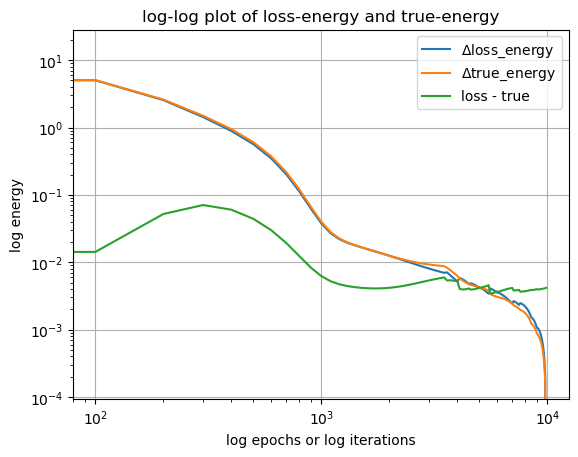

In [10]:
# Plot
plt.figure()
plt.plot(epochs, loss_energy-loss_energy[-1] ,label='$\\Delta$loss_energy')
plt.plot(epochs, true_energy-true_energy[-1] ,label='$\\Delta$true_energy')
plt.plot(epochs, np.abs(loss_energy - true_energy),label='loss - true')
plt.xlabel("log epochs or log iterations")
plt.ylabel("log energy")
plt.title("log-log plot of loss-energy and true-energy")
plt.grid(True)
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()

# Compare with LAMMPS

In [11]:
from shared_lammps_2D import *

LAMMPS_DIR          =   "./lammps_2d_input_output/"
LAMMPS_TRAJ_FILE    =   LAMMPS_DIR + "relax_2d_traj.lammpstrj"
LAMMPS_ENERGY_LOG   =   LAMMPS_DIR + "relax_2d_energy.log"

### Read in the LAMMPS `trajectory` file

In [12]:
timesteps, lammps_frames = read_lammps_trajectory_xy(LAMMPS_TRAJ_FILE)

print(timesteps.shape)
print(lammps_frames.shape)
# shape: (n_frames, n_atoms, 2)

(101,)
(101, 2450, 2)


## Evaluate the `relative-error` in `displacement-vector-field`
$$ \vec{e(t)}_{disp}  = \frac{\lVert \vec{u(t)}_P - \vec{u(t)}_L \rVert}{\lVert \vec{u(t)}_{L} \rVert} $$
- $\vec{u(t)}_P$ is the displacement field predicted by the PINN model at epoch $t$
- $\vec{u(t)}_L$ is the displacement field evaluated by the LAMMPS simulation at iteration $t$

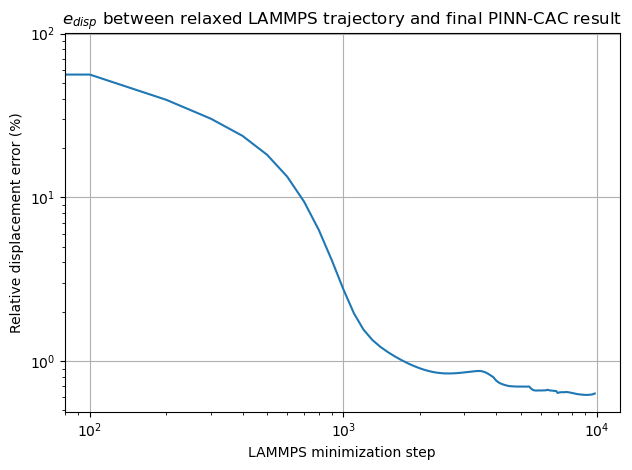

In [13]:
def relative_displacement_error(u_ref, u_pred):
    return np.linalg.norm(u_ref - u_pred) / np.linalg.norm(u_ref)

errors = []

for i in range(1,len(pos)):
    u_lammps = lammps_frames[i] - atom_pos
    u_pinn = pos[i]  - atom_pos
    err = relative_displacement_error(u_lammps,u_pinn)
    errors.append(err)
errors = np.array(errors)

plt.figure()
plt.plot(np.arange(len(errors))*100, 100*errors)
plt.xlabel("LAMMPS minimization step")
plt.ylabel("Relative displacement error (%)")
plt.title("$e_{disp}$ between relaxed LAMMPS trajectory and final PINN-CAC result")
plt.grid(True)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.show()

In [14]:
u_lammps_mags = np.linalg.norm(lammps_frames-atom_pos,axis=2)
u_pinn_mags = np.linalg.norm(pos-atom_pos,axis=2)
relative_err_mags = (np.linalg.norm(lammps_frames[1:]-pos,axis=2)/np.linalg.norm(lammps_frames[1:],axis=2))

/tmp/ipykernel_3265403/2592136731.py:3: RuntimeWarning: invalid value encountered in divide
  relative_err_mags = (np.linalg.norm(lammps_frames[1:]-pos,axis=2)/np.linalg.norm(lammps_frames[1:],axis=2))


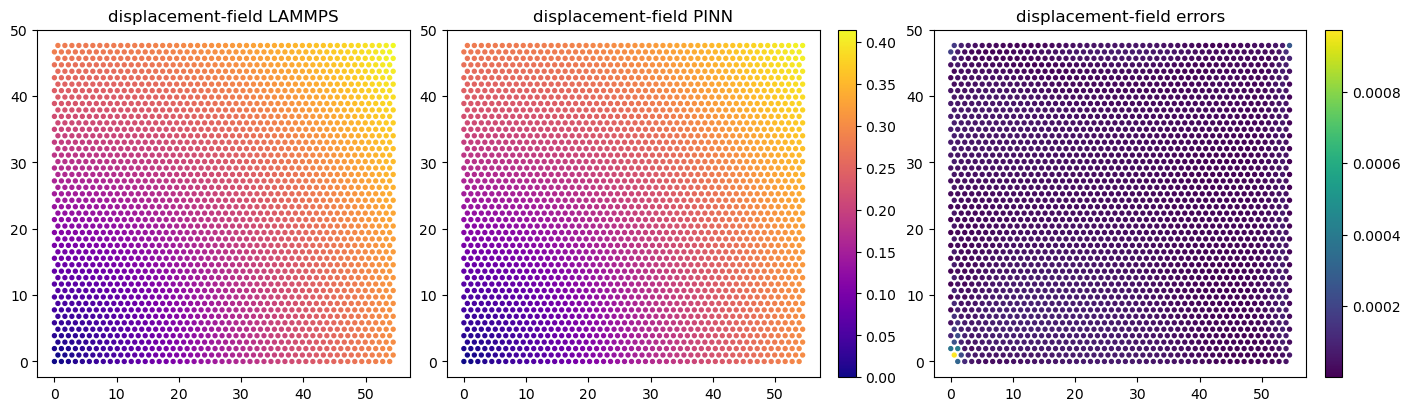

In [15]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4), layout='constrained')

vmin = np.min([np.min(u_pinn_mags[-1]),np.min(u_lammps_mags[-1])])
vmax = np.max([np.max(u_pinn_mags[-1]),np.max(u_lammps_mags[-1])])

scatter_lammps = ax1.scatter(atom_pos[:, 0],atom_pos[:, 1],c=u_lammps_mags[-1],cmap='plasma',s=8,alpha=1,label='LAMMPS',vmin=vmin,vmax=vmax)
scatter_pinn = ax2.scatter(atom_pos[:, 0],atom_pos[:, 1],c=u_pinn_mags[-1],cmap='plasma',s=8,alpha=1,label='PINN',vmin=vmin,vmax=vmax)
cbar_shared = fig.colorbar(scatter_pinn)
ax1.set_title("displacement-field LAMMPS")
ax2.set_title("displacement-field PINN")

scatter_error = ax3.scatter(atom_pos[:, 0],atom_pos[:, 1],c=relative_err_mags[-1],cmap='viridis',s=8,alpha=1,label='error')
cbar_error = fig.colorbar(scatter_error)
ax3.set_title("displacement-field errors")

plt.show()

## Evaluate the `relative-error` in `bond-length-vector`
$$ \vec{err(t)}_{bond}  = \frac{\lVert \vec{b(t)}_P - \vec{b(t)}_L \rVert}{\lVert \vec{b(t)}_{L} \rVert} $$
- bond-length is a vector $\vec{b} = \{b_1, b_2, b_3, ... b_{N_A} \}$ where $b_i$ is the bond-length of atom $i$
- Bond-Length of atom $a$ is given by $\frac{1}{2} \Sigma_{b} \lVert \vec{r_a(t)} - \vec{r_b(t)} \rVert$ where the summation is over all atoms $b$ in the first-nearest-neighbor of atom $a$
- $\vec{b(t)}_P$ is the bond-length vector predicted by the PINN model at epoch $t$
- $\vec{b(t)}_L$ is the bond-length vector evaluated by the LAMMPS simulation at iteration $t$
- NOTE: first-neighbors are evaluated at the referernce configuration (zeroth iteration) 

In [17]:
# find the bond-length-vectors at all times
bond_lengths_lammps = []
bond_lengths_pinn = []
bond_lengths_errors = []
for i in range(len(pos)):
    err_bond, b_lammps, b_pinn = relative_bond_length_error(
        pos0=atom_pos,
        pos_lammps=lammps_frames[i+1],
        pos_pinn=pos[i],
        spacing=2**(1/6),
    )
    bond_lengths_errors.append(err_bond)
    bond_lengths_lammps.append(b_lammps)
    bond_lengths_pinn.append(b_pinn)

bond_lengths_errors = np.array(bond_lengths_errors)
bond_lengths_lammps = np.array(bond_lengths_lammps)
bond_lengths_pinn = np.array(bond_lengths_pinn)

print(f"bond-length error at final iteration/epoch = {100 * bond_lengths_errors[-1]:.6f}%")

bond-length error at final iteration/epoch = 0.020199%


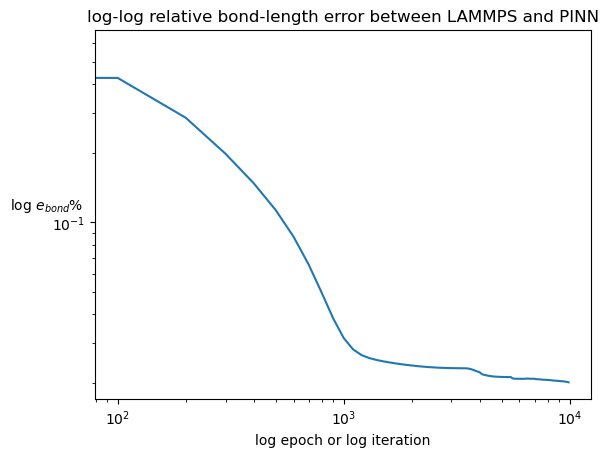

In [18]:
plt.plot(epochs,100*bond_lengths_errors)
plt.yscale('log')
plt.xscale('log')
plt.title('log-log relative bond-length error between LAMMPS and PINN')
plt.xlabel('log epoch or log iteration')
plt.ylabel('log $e_{bond}$%',rotation=0)
plt.show()

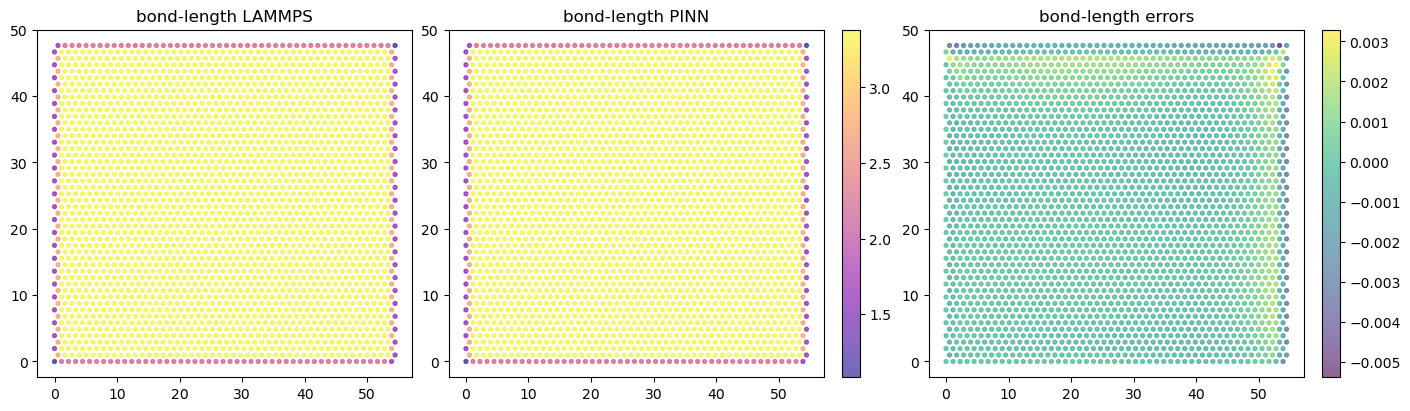

In [19]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4), layout='constrained')
vmin = np.min([np.min(bond_lengths_lammps),np.min(bond_lengths_pinn)])
vmax = np.max([np.max(bond_lengths_lammps),np.max(bond_lengths_pinn)])
scatter_lammps = ax1.scatter(atom_pos[:, 0],atom_pos[:, 1],c=bond_lengths_lammps[-1],cmap='plasma',s=8,alpha=0.6,label='LAMMPS',vmin=vmin,vmax=vmax)
scatter_pinn = ax2.scatter(atom_pos[:, 0],atom_pos[:, 1],c=bond_lengths_pinn[-1],cmap='plasma',s=8,alpha=0.6,label='PINN',vmin=vmin,vmax=vmax)
cbar_shared = fig.colorbar(scatter_pinn)
ax1.set_title("bond-length LAMMPS")
ax2.set_title("bond-length PINN")

scatter_error = ax3.scatter(atom_pos[:, 0],atom_pos[:, 1],c=bond_lengths_pinn[-1]-bond_lengths_lammps[-1],cmap='viridis',s=8,alpha=0.6,label='error')
cbar_error = fig.colorbar(scatter_error)
ax3.set_title("bond-length errors")

plt.show()

## Evaluate the `relative-error` in `total-energy`
$$ err(t)_{E}  = \frac{\lVert E(t)_P - E(t)_L \rVert}{\lVert E(t)_L \rVert} $$
- $E(t)_P$ is the total `coarse-grained-energy` predicted by the PINN model at epoch $t$. 
- $E(t)_L$ is the total `atomistic-energy` evaluated by the LAMMPS simulation at iteration $t$
- The `coarse-grained-energy` is the `loss` function in the PINN. 

### Read in the LAMMPS `energy-logs`

In [20]:
steps, pe, fnorm, fmax = read_lammps_thermo_energy(LAMMPS_ENERGY_LOG)

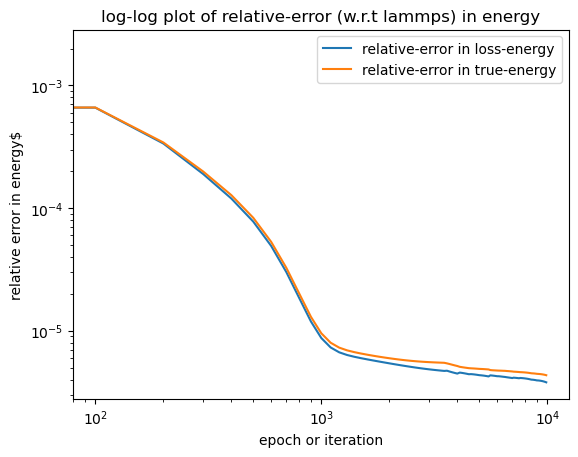

In [21]:
loss_energy_err = np.abs(loss_energy - pe[1:])/np.abs(pe[1:])
true_energy_err = np.abs(true_energy - pe[1:])/np.abs(pe[1:])
plt.plot(epochs,loss_energy_err,label='relative-error in loss-energy')
plt.plot(epochs,true_energy_err,label='relative-error in true-energy')
plt.yscale('log')
plt.xscale('log')
plt.title('log-log plot of relative-error (w.r.t lammps) in energy')
plt.ylabel('relative error in energy$')
plt.xlabel('epoch or iteration')
plt.legend()
plt.show()

# Export reclustering as GIF

In [24]:
from matplotlib.animation import FuncAnimation, PillowWriter

def load_pinn_history(json_filename):
    with open(json_filename, "r") as f:
        history = json.load(f)
    return history


def animate_pinn_history_gif(json_filename,output_gif="pinn_relaxation.gif",fps=10):
    
    history = load_pinn_history(json_filename)

    if len(history) == 0:
        raise ValueError("JSON history is empty.")

    # Collect all positions to set fixed axis limits
    all_pos = np.array([entry["pos"] for entry in history], dtype=np.float64)
    # shape: (n_frames, n_atoms, 2)

    n_frames, n_atoms, dim = all_pos.shape

    x_min = all_pos[:, :, 0].min()
    x_max = all_pos[:, :, 0].max()
    y_min = all_pos[:, :, 1].min()
    y_max = all_pos[:, :, 1].max()

    pad_x = 0.05 * (x_max - x_min)
    pad_y = 0.05 * (y_max - y_min)

    fig, ax = plt.subplots(figsize=(8, 7))

    # Initial frame
    pos0 = all_pos[0]

    atoms_scatter = ax.scatter(pos0[:, 0],pos0[:, 1],s=8)

    rep_indices0 = np.array(history[0]["rep_indices"], dtype=int)
    rep_pos0 = pos0[rep_indices0]

    reps_scatter = ax.scatter(rep_pos0[:, 0],rep_pos0[:, 1],s=120,facecolors="none",edgecolors="red",linewidths=2,)

    title = ax.set_title("")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(x_min - pad_x, x_max + pad_x)
    ax.set_ylim(y_min - pad_y, y_max + pad_y)

    def update(frame_id):
        entry = history[frame_id]

        pos = np.array(entry["pos"], dtype=np.float64)
        epoch = entry["epoch"]
        loss_energy = entry["loss_energy"]
        true_energy = entry.get("true_energy", None)

        atoms_scatter.set_offsets(pos)

        rep_indices = np.array(entry["rep_indices"], dtype=int)
        rep_pos = pos[rep_indices]
        reps_scatter.set_offsets(rep_pos)

        title.set_text(f"PINN 2D re-clustering\nepoch={epoch}, loss={loss_energy:.6e}, true_energy={true_energy:.6e}")

        artists = [atoms_scatter, title]

        if reps_scatter is not None:
            artists.append(reps_scatter)

        return artists

    anim = FuncAnimation(fig,update,frames=n_frames,interval=1000 / fps,blit=False,)

    writer = PillowWriter(fps=fps)
    anim.save(output_gif, writer=writer, dpi=120)

    plt.close(fig)

    print(f"Saved GIF to: {output_gif}")

In [26]:
animate_pinn_history_gif(
    json_filename=PINN_HISTORY_JSON_FILENAME,
    output_gif="figs/pinn_2d_reclustering.gif",
    fps=2)

Saved GIF to: figs/pinn_2d_reclustering.gif


![Alt Text](figs/pinn_2d_reclustering.gif)